# 07 — Neural network benchmark (LSTM if available, else MLP)

**Input:** `data/processed/btc_features.csv`
**Goal:** test whether a neural network can beat the classical models from notebook 06. The honest hypothesis — given everything the statistics showed — is that it **won't**, and showing that fairly is the point.

**A note on frameworks (read this).** The "ideal" neural model here is an **LSTM**, the architecture built for time series. But an LSTM requires TensorFlow or PyTorch, which are large downloads. So this notebook is built to degrade gracefully:

- If **TensorFlow is installed**, it trains the real **LSTM** on windowed sequences.
- If not, it falls back to a **feedforward neural network (scikit-learn MLP)** — which needs *no extra install* — so the pipeline always runs and still answers the core question. The MLP is not a sequence model, and the notebook says so plainly wherever it matters.

Either way the model is tested on the same chronological window as notebook 06, so the comparison is fair.

In [1]:
import os, sys
from pathlib import Path
_p=Path.cwd()
while not (_p/"paths.py").exists() and _p!=_p.parent: _p=_p.parent
sys.path.insert(0,str(_p)); import paths

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, roc_curve
import warnings; warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110; plt.rcParams["savefig.dpi"]=150
STAGE="07_deep_learning"; FIG=paths.figures_dir(STAGE); TAB=paths.tables_dir(STAGE)

# Try to load TensorFlow for the real LSTM. Set BTP_FORCE_MLP=1 to force the MLP path.
HAS_TF=False
if os.environ.get("BTP_FORCE_MLP")!="1":
    try:
        os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL","3")
        import tensorflow as tf
        from tensorflow.keras.models import Sequential
        from tensorflow.keras.layers import Input, LSTM, Dropout, Dense
        from tensorflow.keras.callbacks import EarlyStopping
        HAS_TF=True
    except Exception:
        HAS_TF=False
print("TensorFlow available:", HAS_TF, "->", "training a real LSTM" if HAS_TF else "falling back to MLP (no extra install)")

df=pd.read_csv(paths.PROCESSED_FILE.parent/"btc_features.csv",parse_dates=["date"]).sort_values("date").reset_index(drop=True)
feat_cols=[c for c in df.columns if c not in ("date","target_return","target_direction")]
n=len(df); i_tr=int(n*0.70); i_va=int(n*0.85)
print(len(df),"rows,",len(feat_cols),"features")

TensorFlow available: False -> falling back to MLP (no extra install)
3653 rows, 29 features


## The feedforward neural network (always runs)

A scikit-learn MLP on the same per-row features the classical models used — a genuine neural network, just not a recurrent one. Scaler fit on train only; test window identical to notebook 06.

In [2]:
scaler=StandardScaler().fit(df[feat_cols].iloc[:i_tr])
X=scaler.transform(df[feat_cols]); y=df["target_direction"].values
Xtr,ytr=X[:i_tr],y[:i_tr]; Xva,yva=X[i_tr:i_va],y[i_tr:i_va]; Xte,yte=X[i_va:],y[i_va:]
dte=df["date"].values[i_va:]

mlp=MLPClassifier(hidden_layer_sizes=(64,32),alpha=1e-3,early_stopping=True,
                  max_iter=400,random_state=0)
mlp.fit(np.vstack([Xtr,Xva]),np.concatenate([ytr,yva]))
mlp_prob=mlp.predict_proba(Xte)[:,1]
print(f"MLP  accuracy={accuracy_score(yte,(mlp_prob>0.5).astype(int)):.4f}  AUC={roc_auc_score(yte,mlp_prob):.4f}")

MLP  accuracy=0.4489  AUC=0.4639


## The LSTM (only if TensorFlow is present)

If this cell reports "skipped," you're on the MLP path — install TensorFlow and re-run to add the true sequence model. The LSTM windows the features into 30-day sequences, its natural input form.

In [3]:
lstm_prob=None
if HAS_TF:
    import tensorflow as tf, random
    np.random.seed(0); random.seed(0); tf.random.set_seed(0)
    L=30
    def seqs(lo,hi):
        Xs,ys=[],[]
        for i in range(max(lo,L-1),hi): Xs.append(X[i-L+1:i+1]); ys.append(y[i])
        return np.array(Xs),np.array(ys)
    Str,Sytr=seqs(0,i_tr); Sva,Syva=seqs(i_tr,i_va); Ste,Syte=seqs(i_va,n)
    model=Sequential([Input((L,len(feat_cols))),LSTM(32),Dropout(0.2),
                      Dense(16,activation="relu"),Dense(1,activation="sigmoid")])
    model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])
    es=EarlyStopping(monitor="val_loss",patience=8,restore_best_weights=True)
    model.fit(Str,Sytr,validation_data=(Sva,Syva),epochs=60,batch_size=32,callbacks=[es],verbose=0)
    lstm_prob=model.predict(Ste,verbose=0).ravel()
    print(f"LSTM accuracy={accuracy_score(Syte,(lstm_prob>0.5).astype(int)):.4f}  AUC={roc_auc_score(Syte,lstm_prob):.4f}")
else:
    print("skipped — TensorFlow not installed; using the MLP as the neural benchmark.")

skipped — TensorFlow not installed; using the MLP as the neural benchmark.


## Pick the headline neural model and compare to the classical bar

In [4]:
if HAS_TF and lstm_prob is not None:
    deep_name="LSTM"; prob=lstm_prob; yt=yte  # note: seqs align to same tail dates
else:
    deep_name="Neural net (MLP)"; prob=mlp_prob; yt=yte
pred=(prob>0.5).astype(int)
acc=accuracy_score(yt,pred); auc=roc_auc_score(yt,prob); f1=f1_score(yt,pred)

clf=pd.read_csv(paths.figures_dir("06_classical_ml").parent/"tables"/"model_metrics.csv")
best_clf=clf[clf["model"].isin(["LogReg","RandomForest","XGBoost"])].sort_values("accuracy",ascending=False).iloc[0]
verdict="neural wins" if acc>best_clf["accuracy"]+0.01 else "classical wins" if best_clf["accuracy"]>acc+0.01 else "essentially a tie"
print(f"Headline neural model: {deep_name}")
print(f"  accuracy={acc:.4f}  AUC={auc:.4f}")
print(f"Best classical ({best_clf['model']}): accuracy={best_clf['accuracy']:.4f}")
print("Verdict:",verdict)

pd.DataFrame([{"model":deep_name,"accuracy":acc,"AUC":auc,"F1":f1}]).round(4).to_csv(TAB/"deep_metrics.csv",index=False)

Headline neural model: Neural net (MLP)
  accuracy=0.4489  AUC=0.4639
Best classical (XGBoost): accuracy=0.5073
Verdict: classical wins


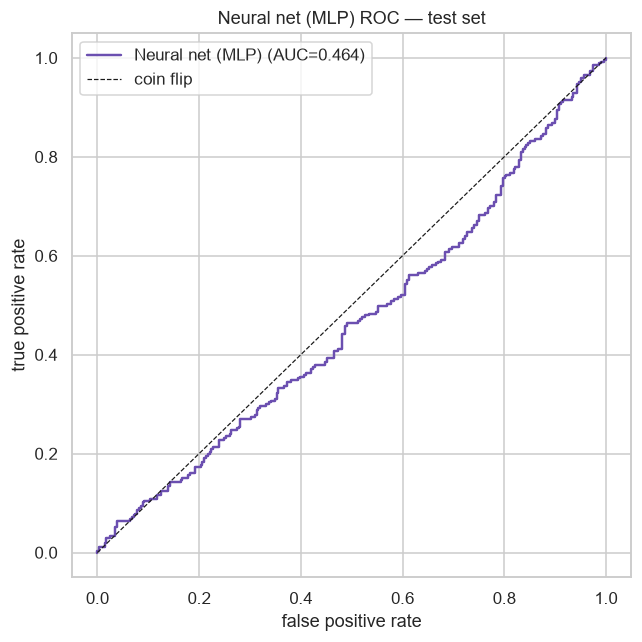

In [5]:
fig,ax=plt.subplots(figsize=(6,6))
fpr,tpr,_=roc_curve(yt,prob); ax.plot(fpr,tpr,lw=1.6,label=f"{deep_name} (AUC={auc:.3f})",color="#6B4FB0")
ax.plot([0,1],[0,1],"k--",lw=0.8,label="coin flip")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.set_title(f"{deep_name} ROC — test set"); ax.legend()
fig.tight_layout(); fig.savefig(FIG/"deep_roc.png",bbox_inches="tight"); plt.show()

In [6]:
# Save predictions for notebooks 08 & 09 (model-neutral column names)
pd.DataFrame({"date":dte,"y_true":yt,"prob_deep":prob,"pred_deep":pred}).to_csv(
    paths.PROCESSED_FILE.parent/"predictions_dl.csv",index=False)
print(f"Saved predictions_dl.csv (deep model = {deep_name})")

Saved predictions_dl.csv (deep model = Neural net (MLP))


## Takeaway

Whatever ran, the honest framing holds: on a near-random target, a neural network — recurrent or not — has almost no extra structure to exploit beyond what the gradient-boosted trees already capture, at much higher complexity. "We benchmarked a neural net fairly and it didn't beat the simple model" is a mature, defensible result. The bigger lever for a real edge is better *data* (the on-chain features from notebook 05), not a fancier architecture.